# 07 — Criação do Dataset & Motor de Instruções (BIA)

## Introdução

### Objetivo
Construir um pipeline **fim a fim** para gerar e validar um **dataset de instruções** (mensagens rotuladas por intenção) e um **motor de resposta** híbrido (regras + ML/BERTimbau) alinhado ao `fluxos.yaml`. O notebook:
- Consolida artefatos (classificador prévio, label encoder, thresholds, `label_map.yaml`, `fluxos.yaml`);
- Normaliza rótulos para o **conjunto canônico** de intents (do `fluxos.yaml`);
- Extrai **entidades-chave** (CEP, id de pedido, tamanho, categoria) e aplica **regras heurísticas**;
- Combina predição por **ML** com **máquina de estados** + templates;
- Avalia contra rótulos do NB03, **identifica confusões**, exporta erros e **gera dataset balanceado** para re/treino;
- Fine-tuna e publica um **BERTimbau** compatível (labels/id2label), e integra ao `respond()`.

### Perguntas-guia (o que o leitor leva desta etapa)
1. Quais são as **intents canônicas** e como garantir que rótulos divergentes colapsem para elas?  
2. Como **threshold** e **gap top-2** impactam “outros” vs. assertividade?  
3. Onde estão as **confusões mais frequentes** (verdadeiro → previsto) e o que priorizar de curadoria?  
4. O motor (estados/transições/guards) está **coerente** com os templates e com as **entidades** extraídas?  
5. O pipeline é **idempotente e portátil** (paths, fallbacks, parquet/CSV, patches de engine/service/actions)?  
6. O dataset final atende aos **requisitos de treino** (split estratificado, balanceamento, mapeamento estável de labels)?

### Etapas (visão resumida)
1) Setup de ambiente e **paths** (repo, `code/resources`, `notebook07_{inputs,outputs}`)  
2) Carga de **artefatos de modelo** (classifier/LE/embedding) + **thresholds** com fallback  
3) Leitura do `fluxos.yaml` e do `label_map.yaml` → **normalização/collapse** para intents canônicas  
4) **Extração de entidades** + **regras** (NLU heurístico) e **predição ML** com `THRESH`/`GAP_TOP2`  
5) **State machine** (guards, actions, templates) e render de resposta  
6) **Classificação em lote** de CSV novo (INBOX) e **avaliação** com NB03 (report + matriz de confusão)  
7) **Sweep** de thresholds; **debug** e checagem de consistência modelo ↔ YAML  
8) **Exports**: misclassifications, dataset balanceado p/ re/treino; **catálogo** normalizado (parquet/CSV)  
9) **Patches** idempotentes (engine/service/actions/templates)  
10) **Fine-tuning BERTimbau** (Datasets/Transformers), **salvar** artefatos, **publicar** no Hub e **trocar** `predict_ml` → BERT

### Saídas (principais)
- `notebook07_outputs/`:  
  - `misclassified_for_retrain.csv`, `balanced_nb03_for_training.csv`, `bert_{train,val}_preview.csv`  
  - `catalogo_normalizado.parquet` (ou `.csv`) + `catalogo_pointer.txt`  
  - `modelos/bertimbau_intents/` (modelo + tokenizer + `labels.json`)  
  - `modelos/thresholds.json` atualizado  
- `resources/fluxos.yaml` atualizado (template `sugestoes_result`, ações padronizadas)

In [ ]:
# CÉLULA 1 — Imports, helpers e banner
# ---------------------------------------------------------------
# Objetivo: preparar o ambiente (imports), funções utilitárias de
# normalização e um banner com informações do runtime.

from pathlib import Path
from datetime import datetime
import platform, sys, os, re, json, unicodedata
import numpy as np
import pandas as pd

def strip_accents(s: str) -> str:
    """Remove acentos com NFD (leve). Mantém não-strings intactas."""
    if not isinstance(s, str):
        return s
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def norm_space(s: str) -> str:
    """Normaliza espaços (colapsa múltiplos em um) e faz strip nas pontas."""
    return re.sub(r"\s+", " ", str(s)).strip()

def find_repo_root():
    """Sobe pastas a partir do CWD até encontrar a estrutura esperada (code/resources)."""
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "code").exists() and (p / "code" / "resources").exists():
            return p
    return here

# Banner de diagnóstico (ajuda a reproduzir execuções em ambientes diferentes)
print(">> NB06 — Análise Semântica (Embeddings, Redução e Clusters)")
print("Base:", Path.cwd())
print("SO:", platform.platform())
print("Início:", datetime.now().strftime("%Y-%m-%dT%H:%M:%S"))

>> NB06 — Análise Semântica (Embeddings, Redução e Clusters)
Base: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks
SO: Windows-10-10.0.19045-SP0
Início: 2025-09-11T16:24:07


In [ ]:
# CÉLULA 2 — Caminhos do projeto (fixos e limpos)
# ---------------------------------------------------------------
# Objetivo: definir estrutura de diretórios e criar pastas de I/O
# deste notebook (INBOX/OUTBOX).

REPO_ROOT     = find_repo_root()
CODE_DIR      = REPO_ROOT / "code"
RESOURCES_DIR = CODE_DIR / "resources"
NOTEBOOKS_DIR = CODE_DIR / "notebooks"
NB_DIR        = NOTEBOOKS_DIR / "06"  # mantemos a pasta do NB06 para insumos

# I/O deste NB
INBOX  = NB_DIR / "inputs"                     # (opcional) insumos locais deste NB
OUTBOX = NOTEBOOKS_DIR / "notebook08_outputs"  # saídas padronizadas para o NB08
INBOX.mkdir(parents=True, exist_ok=True)
OUTBOX.mkdir(parents=True, exist_ok=True)

# Logs de paths (úteis para debug)
print("REPO_ROOT    :", REPO_ROOT)
print("CODE_DIR     :", CODE_DIR)
print("RESOURCES_DIR:", RESOURCES_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)
print("NB_DIR       :", NB_DIR)
print("INBOX        :", INBOX)
print("OUTBOX       :", OUTBOX)

REPO_ROOT    : c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04
CODE_DIR     : c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code
RESOURCES_DIR: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources
NOTEBOOKS_DIR: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks
NB_DIR       : c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\06
INBOX        : c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\06\inputs
OUTBOX       : c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs


In [ ]:
# CÉLULA 3 — Carrega label_map.yaml (normalize/collapse) + intents do fluxos.yaml
# ---------------------------------------------------------------
# Objetivo: centralizar a normalização de rótulos; usar intents do
# fluxos.yaml como conjunto canônico; definir funções auxiliares
# (norm_label, collapse_label, to_canonical).

import yaml, re, unicodedata

# label_map com regras de normalização/colapsos/aliases
LABELMAP_FILE = RESOURCES_DIR / "label_map.yaml"
assert LABELMAP_FILE.exists(), f"label_map.yaml não encontrado em {LABELMAP_FILE}"
LABELMAP = yaml.safe_load(LABELMAP_FILE.read_text(encoding="utf-8")) or {}

# fluxos.yaml define o conjunto canônico de intents aceitas
FLOW_YAML = RESOURCES_DIR / "fluxos.yaml"
assert FLOW_YAML.exists(), f"fluxos.yaml não encontrado em {FLOW_YAML}"
FLOW_DOC = yaml.safe_load(FLOW_YAML.read_text(encoding="utf-8")) or {}
VALID_INTENTS = set(FLOW_DOC.get("intents", []))

# Parâmetros de normalização vindos do label_map.yaml (com defaults sensatos)
NMZ = LABELMAP.get("normalize", {})
CASEFOLD      = bool(NMZ.get("casefold", True))
STRIP_ACCENTS = bool(NMZ.get("strip_accents", True))
REPLACE_MAP   = NMZ.get("replace", {}) or {}

# Outras convenções do label_map
UNKNOWN_TO = LABELMAP.get("unknown_to", "outros")
COL_ALIAS  = LABELMAP.get("column_aliases", {
    "texto":  ["texto","mensagem","utterance","frase","message"],
    "intent": ["intent","intencao","intenção","label","rotulo","rótulo","classe","target","y","label_regra"],
})
COLLAPSE   = LABELMAP.get("collapse_to", {})
DROP_LABS  = set(LABELMAP.get("drop", []))

def strip_accents(s: str) -> str:
    """Helper local (NFD) para remover acentos."""
    if not isinstance(s, str): return s
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def norm_label(raw: str) -> str:
    """Normaliza um rótulo textual: acentos, casefold, replace, underscoring."""
    if not isinstance(raw, str):
        return UNKNOWN_TO
    s = raw
    if STRIP_ACCENTS: s = strip_accents(s)
    if CASEFOLD:      s = s.casefold()
    s = s.strip()
    for a, b in REPLACE_MAP.items():
        s = s.replace(a, b)
    s = re.sub(r"\s+", "_", s)
    return s

def collapse_label(lbl: str) -> str:
    """Aplica mapeamentos de variantes → canônico (se definidos no label_map)."""
    for canon, variants in COLLAPSE.items():
        if lbl == canon or lbl in [norm_label(v) for v in variants]:
            return canon
    return lbl

def to_canonical(lbl: str) -> str:
    """Normaliza + colapsa e garante pertinência ao conjunto de VALID_INTENTS."""
    key = collapse_label(norm_label(lbl))
    return key if key in VALID_INTENTS else UNKNOWN_TO

# Logs de conferência (facilitam inspeção de configurações ativas)
print("✓ label_map carregado de:", LABELMAP_FILE)
print("→ Aliases de colunas:", COL_ALIAS)
if COLLAPSE:  print("→ Colapsos definidos:", COLLAPSE)
if DROP_LABS: print("→ Rótulos a descartar:", sorted(DROP_LABS))
print("→ Intents canônicas (fluxos.yaml):", len(VALID_INTENTS))

✓ label_map carregado de: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\label_map.yaml
→ Aliases de colunas: {'texto': ['texto', 'mensagem', 'utterance', 'frase', 'message'], 'intent': ['intent', 'intencao', 'intenção', 'label', 'rotulo', 'rótulo', 'classe', 'target', 'y', 'label_regra']}
→ Colapsos definidos: {'outros': ['outros_cluster']}
→ Rótulos a descartar: ['', 'n/a']
→ Intents canônicas (fluxos.yaml): 24


In [ ]:
# CÉLULA 4 — Carrega dataset (NB03 → fallback para CSV manual)
# ---------------------------------------------------------------
# Objetivo: carregar o conjunto de mensagens a clusterizar. Preferência:
# 1) saída consolidada do NB03; 2) CSV manual em INBOX.

# Preferência 1: NB03 consolidado
NB03_CSV = NOTEBOOKS_DIR / "notebook03_outputs" / "mensagens_rotulos_resumo.csv"
# Preferência 2: CSV manual colocado aqui
ALT_CSV  = INBOX / "mensagens_para_cluster.csv"

# Seleciona fonte disponível
src = None
if NB03_CSV.exists():
    src = NB03_CSV
elif ALT_CSV.exists():
    src = ALT_CSV

# Falha cedo se nada for encontrado (orienta usuário)
assert src is not None, (
    "Nenhum dataset encontrado.\n"
    f"- Coloque {NB03_CSV}\n"
    f"  ou\n"
    f"- Coloque um CSV em {ALT_CSV} com ao menos a coluna de texto."
)
df_raw = pd.read_csv(src)
print("✓ Dataset carregado de:", src)
print("Colunas disponíveis:", list(df_raw.columns))

def pick_col(cols, aliases):
    """Escolhe a primeira coluna que bate com os aliases informados."""
    for a in aliases:
        if a in cols:
            return a
    return None

# Identifica colunas de texto e (opcionalmente) intent
txt_col = pick_col(df_raw.columns, COL_ALIAS.get("texto", ["texto"]))
lab_col = pick_col(df_raw.columns, COL_ALIAS.get("intent", ["intent","label_regra"]))

assert txt_col is not None, "Não achei coluna de TEXTO (ajuste 'column_aliases' no label_map.yaml)."

# Normaliza apenas o texto (intent é opcional)
df = pd.DataFrame({"texto": df_raw[txt_col].astype(str).map(norm_space)})

# Intent serve para colorir/avaliar a projeção; se existir, normaliza e aplica drops
if lab_col is not None:
    labs = df_raw[lab_col].astype(str).map(norm_space)
    labs = labs.map(to_canonical)
    df["intent"] = labs
    # Remove intents descartáveis (se configurado no label_map)
    if DROP_LABS:
        before = len(df)
        df = df[~df["intent"].isin(DROP_LABS)]
        print(f"→ Removi {before-len(df)} linha(s) por 'drop' do label_map.")
else:
    df["intent"] = "sem_rotulo"

# Pré-visualização e shape (sanity)
print(df.head(3))
print("shape:", df.shape)

✓ Dataset carregado de: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook03_outputs\mensagens_rotulos_resumo.csv
Colunas disponíveis: ['ts', 'autor', 'texto', 'origem', 'label_regra', 'candidatos']
→ Removi 0 linha(s) por 'drop' do label_map.
                                               texto          intent
0                                                  😍          outros
1                                     😍 body mybasic          outros
2  oi bia, tudo bem? adorei a @curadabia, (o nome...  duvida_tamanho
shape: (1025, 2)


In [ ]:
# CÉLULA 5 — Embeddings (reaproveita o mesmo nome salvo no NB05)
# ---------------------------------------------------------------
# Objetivo: transformar frases em vetores densos via Sentence-Transformers,
# preferindo o mesmo embedder usado no NB05 (para consistência).

from sentence_transformers import SentenceTransformer

# Pastas candidatas para o arquivo embedding_model_name.txt
CANDIDATE_EMB_DIRS = [
    NOTEBOOKS_DIR / "modelos",  # artefatos do NB05 (padrão do projeto)
    NB_DIR / "modelos",         # caso você copie artefatos para este NB06
]

# Procura o arquivo com o nome do modelo de embeddings; se não achar, usa fallback
EMB_FILE = None
for d in CANDIDATE_EMB_DIRS:
    f = d / "embedding_model_name.txt"
    if f.exists():
        EMB_FILE = f
        break

# fallback seguro (multilíngue e leve)
if EMB_FILE is None:
    EMB_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    print("⚠️ embedding_model_name.txt não encontrado; usando fallback:", EMB_NAME)
else:
    EMB_NAME = EMB_FILE.read_text(encoding="utf-8").strip()

# Carrega o embedder selecionado
EMB = SentenceTransformer(EMB_NAME)
print("✓ Embedder:", EMB_NAME)

# Codifica os textos; salva os embeddings e o CSV base (texto/intent)
X = EMB.encode(df["texto"].astype(str).tolist(), show_progress_bar=True)
np.save(OUTBOX / "embeddings.npy", X)
df.to_csv(OUTBOX / "dados_embed.csv", index=False, encoding="utf-8")
print("Embeddings:", X.shape, "→ salvo em:", OUTBOX / "embeddings.npy")

✓ Embedder: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Embeddings: (1025, 384) → salvo em: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\embeddings.npy


c:\Users\decoH\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP 2D gerado: (1025, 2)


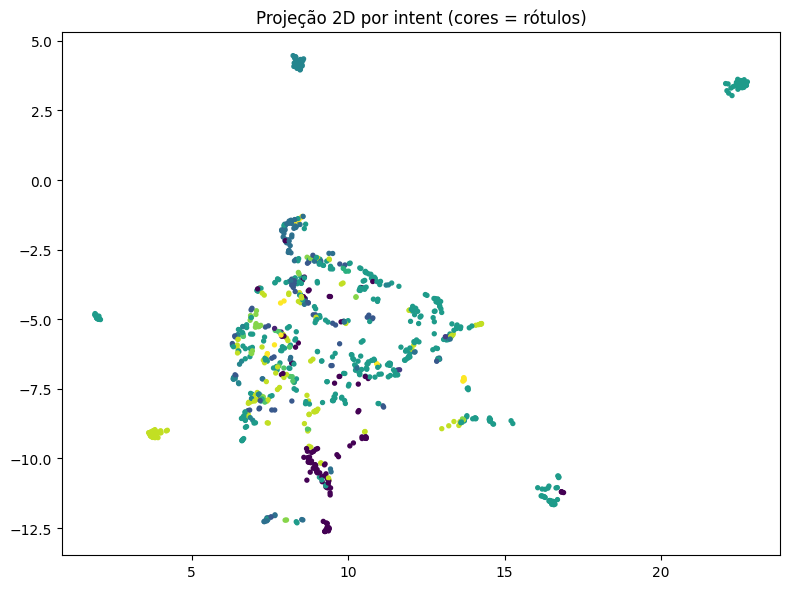

In [ ]:
# CÉLULA 6 — Redução de dimensionalidade (UMAP → fallback PCA)
# ---------------------------------------------------------------
# Objetivo: reduzir para 2D para visualização e (opcionalmente) clustering.
# Tenta UMAP (melhor para semântica); caso indisponível, usa PCA 2D.

# Tenta UMAP; se indisponível, usa PCA 2D
X2 = None
try:
    import umap
    um = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    X2 = um.fit_transform(X)
    print("✓ UMAP 2D gerado:", X2.shape)
except Exception as e:
    print("⚠️ UMAP indisponível, usando PCA 2D. Motivo:", e)
    from sklearn.decomposition import PCA
    X2 = PCA(n_components=2, random_state=42).fit_transform(X)
    print("✓ PCA 2D gerado:", X2.shape)

# Persiste a projeção 2D (independente de ser UMAP ou PCA)
np.save(OUTBOX / "umap_2d.npy", X2)

# Plot rápido (se tiver intents, colore por elas)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
if "intent" in df.columns and df["intent"].nunique() > 1:
    labs = df["intent"].astype("category")
    colors = labs.cat.codes
    plt.scatter(X2[:,0], X2[:,1], s=8, c=colors)
    plt.title("Projeção 2D por intent (cores = rótulos)")
else:
    plt.scatter(X2[:,0], X2[:,1], s=8)
    plt.title("Projeção 2D (sem rótulos)")
plt.tight_layout(); plt.show()

# 🧭 Guia Rápido de Projeção & Clusterização

## Projeção (UMAP→PCA fallback)
- **`n_neighbors`**: local (5–15) = microtemas; global (30–50) = macrotopos.
- **`min_dist`**: menor aproxima bolhas compactas (0.0–0.2), maior espalha (0.4+).
- **`metric`**: para embeddings semânticos, **`cosine`** tende a funcionar melhor.

## Clusterização (KMeans)
- Rodamos vários **k** e escolhemos pelo **silhouette** (cosine→euclidean fallback).
- Sinais de k ruim:
  - Muitos clusters com **pouquíssimos pontos**.
  - Clusters gigantes com termos **heterogêneos**.
- Ajustes práticos:
  - Se houver **bolhas bem separadas** no 2D: tente **k maior**.
  - Se houver **ilhas minúsculas** ruidosas: suba `min_cluster_size` (HDBSCAN) ou **reduza k** (KMeans).

> Lembre: a projeção 2D é **diagnóstica**, não “verdade absoluta”. Decisões finais vêm de **top terms** (CÉLULA 8) + **amostras** (CÉLULA 9).


Usando para clusterização: 2D shape: (1025, 2)
Silhouette por k: [(5, -0.15433670580387115), (10, -0.025605829432606697), (15, 0.06283169984817505), (20, -0.039196405559778214), (25, 0.021303219720721245)]
→ k escolhido: 15
✓ clusters salvos em: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs


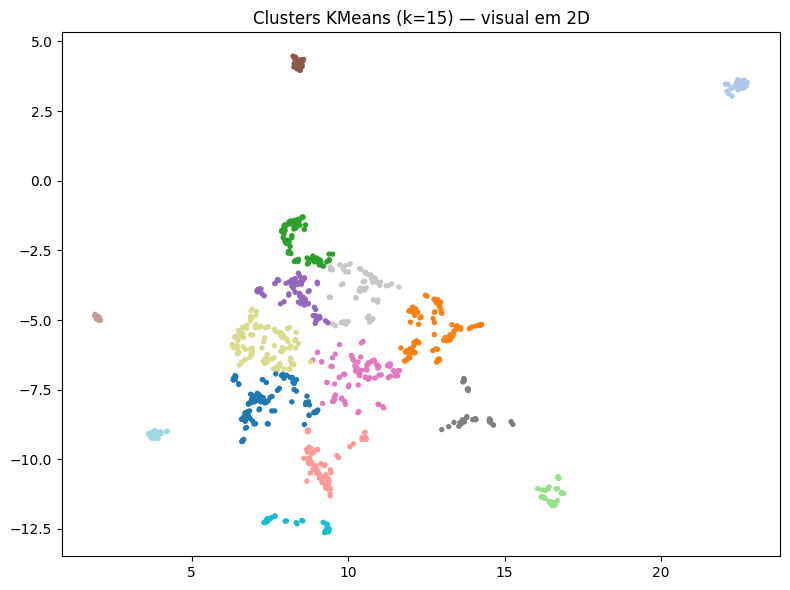

In [ ]:
# CÉLULA 7 — Clusterização (KMeans com silhouette robusto)
# ---------------------------------------------------------------
# Objetivo: escolher k automaticamente com base em silhouette (varrendo k)
# e rotular cada ponto com o cluster correspondente.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Base para clusterização: usa a 2D (visualmente coerente), senão os embeddings originais
Z = X2 if isinstance(X2, np.ndarray) and X2.ndim == 2 else X
print("Usando para clusterização:", "2D" if Z is X2 else "Embeddings orig.", "shape:", Z.shape)

n_samples = Z.shape[0]
if n_samples < 10:
    # Dataset muito pequeno → evita heurística; fixa k=2
    best_k = 2
    scores = [(2, None)]
else:
    # Testa Ks em degraus de 5 (5,10,15,20,25) respeitando tamanho do dataset
    Ks = [k for k in range(5, 26, 5) if 1 < k < n_samples]
    scores = []
    for k in Ks:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        lab = km_tmp.fit_predict(Z)
        sc = -1
        # silhouette precisa de pelo menos 2 clusters e k < n_samples
        if len(set(lab)) > 1 and k < n_samples:
            try:
                sc = silhouette_score(Z, lab, metric="cosine")
            except Exception:
                sc = silhouette_score(Z, lab, metric="euclidean")
        scores.append((k, sc))
    # Escolhe k com melhor silhouette (tratando None como -1)
    best_k, _ = max(scores, key=lambda t: (t[1] if t[1] is not None else -1))

print("Silhouette por k:", scores)
print(f"→ k escolhido: {best_k}")

# Treina KMeans final e anexa labels ao df
km = KMeans(n_clusters=best_k, n_init="auto", random_state=42).fit(Z)
df["cluster"] = km.labels_

# Persistência: labels, tabela de silhouettes e dataset clusterizado
np.save(OUTBOX / "cluster_kmeans_labels.npy", km.labels_)
pd.DataFrame(scores, columns=["k", "silhouette"]).to_csv(OUTBOX / "kmeans_silhouette.csv", index=False, encoding="utf-8")
df.to_csv(OUTBOX / "dados_clusterizados.csv", index=False, encoding="utf-8")

print("✓ clusters salvos em:", OUTBOX)

# Visual rápido por cluster (sempre na projeção 2D)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X2[:,0], X2[:,1], s=8, c=df["cluster"], cmap="tab20")
plt.title(f"Clusters KMeans (k={best_k}) — visual em 2D")
plt.tight_layout(); plt.show()

In [ ]:
# CÉLULA 8 — Sumário dos clusters (top intents e palavras do cluster)
# ---------------------------------------------------------------
# Objetivo: sintetizar cada cluster com termos TF-IDF mais representativos
# e (se houver) as intents mais frequentes.

from sklearn.feature_extraction.text import TfidfVectorizer

def top_terms(corpus, topn=8):
    """Retorna top-n termos (uni/bigramas) por média TF-IDF do cluster."""
    if len(corpus) == 0:
        return []
    vec = TfidfVectorizer(
        max_features=3000,
        ngram_range=(1,2),
        lowercase=True,
        token_pattern=r"(?u)\b\w+\b"
    )
    Xtf = vec.fit_transform(corpus)
    # média TF-IDF por termo (ordena desc)
    mean_tfidf = np.asarray(Xtf.mean(axis=0)).ravel()
    idx = mean_tfidf.argsort()[::-1][:topn]
    feats = np.array(vec.get_feature_names_out())[idx]
    vals  = mean_tfidf[idx]
    return list(zip(feats, np.round(vals, 4)))

def top_intents(series, topn=3):
    """Retorna as intents mais frequentes no cluster (se existirem)."""
    return series.value_counts().head(topn).to_dict()

# Gera resumo cluster a cluster
summary_rows = []
for c_id, grp in df.groupby("cluster", sort=False):
    intents_dict = top_intents(grp["intent"]) if "intent" in grp.columns else {}
    terms = top_terms(grp["texto"].tolist(), topn=8)
    summary_rows.append({
        "cluster": int(c_id),
        "qtd": len(grp),
        "top_intents": intents_dict,
        "top_terms": terms
    })

summary_df = pd.DataFrame(summary_rows).sort_values("qtd", ascending=False)

# Persiste resumo (será usado nas próximas etapas)
summary_df.to_csv(OUTBOX / "clusters_resumo.csv", index=False, encoding="utf-8")
print("✓ resumo salvo em:", OUTBOX / "clusters_resumo.csv")
summary_df.head(10)

✓ resumo salvo em: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\clusters_resumo.csv


,cluster,qtd,top_intents,top_terms
6,12,123,"{'outros': 48, 'preco_pagamento': 19, 'saudaca...","[(compra, 0.0429), (de, 0.0354), (o, 0.0352), ..."
9,2,107,"{'outros': 77, 'saudacao': 18, 'duvida_tamanho...","[(oi, 0.0561), (maravilha, 0.0558), (oie, 0.03..."
4,0,103,"{'saudacao': 33, 'outros': 33, 'onde_comprar':...","[(olá, 0.0955), (e, 0.0486), (de, 0.0425), (co..."
5,9,94,"{'outros': 74, 'agradecimento': 8, 'disponibil...","[(vou, 0.0431), (não, 0.0349), (chegou, 0.0257..."
14,6,86,"{'outros': 40, 'disponibilidade': 16, 'saudaca...","[(a, 0.06), (calça, 0.0487), (é, 0.0405), (de,..."
11,5,85,"{'agradecimento': 68, 'saudacao': 9, 'outros': 4}","[(obrigada, 0.2204), (muito, 0.0787), (muito o..."
1,3,83,"{'duvida_tamanho': 48, 'outros': 19, 'saudacao...","[(tamanho, 0.0469), (de, 0.0432), (a, 0.0415),..."
13,11,75,"{'outros': 47, 'disponibilidade': 8, 'agradeci...","[(que, 0.045), (adorei, 0.0432), (adoro, 0.037..."
0,1,53,{'outros': 53},"[(obaaa, 0.0377), (vamos marcar, 0.0218), (vam..."
10,4,47,"{'outros': 43, 'agradecimento': 4}","[(ok, 0.0851), (perfeito, 0.0647), (tudo, 0.05..."


In [ ]:
# CÉLULA 9 — Amostras por cluster (útil para inspeção humana)
# ---------------------------------------------------------------
# Objetivo: facilitar revisão humana gerando um CSV com até 50 exemplos por cluster.

def sample_by_cluster(df, c_id, n=10):
    """Retorna amostra aleatória de até n exemplos do cluster c_id."""
    sub = df[df["cluster"] == c_id].sample(min(n, (df["cluster"] == c_id).sum()), random_state=42)
    cols = ["texto"]
    if "intent" in df.columns:
        cols.append("intent")
    return sub[cols]

# Gera um CSV com até 50 exemplos por cluster (ordenado por cluster)
samples = []
for c_id in sorted(df["cluster"].unique()):
    take = df[df["cluster"] == c_id].head(50).copy()
    samples.append(take.assign(_cluster=c_id))
samples_df = pd.concat(samples, ignore_index=True)
cols = ["_cluster","texto"] + (["intent"] if "intent" in samples_df.columns else [])
samples_df[cols].to_csv(OUTBOX / "clusters_amostras.csv", index=False, encoding="utf-8")
print("✓ amostras por cluster:", OUTBOX / "clusters_amostras.csv")

✓ amostras por cluster: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\clusters_amostras.csv


In [ ]:
# CÉLULA 10 — Carrega clusters_resumo; fallback: recomputa rapidamente
# ---------------------------------------------------------------
# Objetivo: garantir que teremos um 'resumo_df' válido, lendo do disco
# ou reconstruindo a partir de df/cluster se necessário.

from pathlib import Path
import pandas as pd
import numpy as np
import ast, json, re  # ast/json para parse de colunas serializadas

# Usa OUTBOX já definido no início do NB06
RESUMO = OUTBOX / "clusters_resumo.csv"
AMOSTRAS = OUTBOX / "clusters_amostras.csv"

def _ensure_resumo():
    """Carrega clusters_resumo.csv; se não existir, reconstrói a partir de df."""
    if RESUMO.exists():
        df_r = pd.read_csv(RESUMO)
        # Normaliza coluna 'top_terms' (string -> lista)
        if "top_terms" in df_r.columns:
            # strings tipo "[('termo', 0.12), ...]" → lista de termos
            def parse_terms(s):
                try:
                    val = ast.literal_eval(str(s))
                    return [t[0] if isinstance(t, (list,tuple)) and len(t)>=1 else str(t) for t in val]
                except Exception:
                    return []
            df_r["top_terms_list"] = df_r["top_terms"].map(parse_terms)
        else:
            df_r["top_terms_list"] = [[] for _ in range(len(df_r))]
        # Normaliza 'top_intents' (string -> dict)
        if "top_intents" in df_r.columns:
            def parse_intents(s):
                try: 
                    return json.loads(s.replace("'", '"')) if isinstance(s, str) else {}
                except Exception:
                    # fallback com literal_eval
                    try: return ast.literal_eval(str(s))
                    except Exception: return {}
            df_r["top_intents_dict"] = df_r["top_intents"].map(parse_intents)
        else:
            df_r["top_intents_dict"] = [{} for _ in range(len(df_r))]
        return df_r

    # Fallback: se este NB já rodou até a CÉLULA 8, reaproveita df/cluster
    if "df" in globals() and "cluster" in df.columns:
        # Resumo mínimo sem TF-IDF pesado (contagem simples de tokens)
        def _top_terms_quick(corpus, topn=8):
            toks = re.findall(r"\w+", " ".join([str(x) for x in corpus]).lower())
            if not toks:
                return []
            vc = pd.Series(toks).value_counts().head(topn)
            return list(zip(vc.index.tolist(), vc.values.tolist()))
        rows = []
        for c_id, grp in df.groupby("cluster", sort=False):
            intents_dict = grp["intent"].value_counts().head(3).to_dict() if "intent" in grp.columns else {}
            terms = _top_terms_quick(grp["texto"].tolist(), topn=8)
            rows.append({"cluster":int(c_id), "qtd":len(grp), "top_intents":intents_dict, "top_terms":terms})
        df_r = pd.DataFrame(rows).sort_values("qtd", ascending=False)
        # Adapta colunas auxiliares
        df_r["top_terms_list"] = df_r["top_terms"].map(lambda ts: [t[0] for t in ts] if isinstance(ts, list) else [])
        df_r["top_intents_dict"] = df_r["top_intents"]
        return df_r

    # Se nada deu certo, falha com instrução
    raise FileNotFoundError("Não encontrei clusters_resumo.csv e também não achei df com coluna 'cluster' para fallback.")

# Garante 'resumo_df' pronto para uso
resumo_df = _ensure_resumo().copy()
print("✓ clusters_resumo carregado/gerado — shape:", resumo_df.shape)
resumo_df[["cluster","qtd","top_terms_list","top_intents_dict"]].head(10)

✓ clusters_resumo carregado/gerado — shape: (15, 6)


,cluster,qtd,top_terms_list,top_intents_dict
0,12,123,[],"{'outros': 48, 'preco_pagamento': 19, 'saudaca..."
1,2,107,[],"{'outros': 77, 'saudacao': 18, 'duvida_tamanho..."
2,0,103,[],"{'saudacao': 33, 'outros': 33, 'onde_comprar':..."
3,9,94,[],"{'outros': 74, 'agradecimento': 8, 'disponibil..."
4,6,86,[],"{'outros': 40, 'disponibilidade': 16, 'saudaca..."
5,5,85,[],"{'agradecimento': 68, 'saudacao': 9, 'outros': 4}"
6,3,83,[],"{'duvida_tamanho': 48, 'outros': 19, 'saudacao..."
7,11,75,[],"{'outros': 47, 'disponibilidade': 8, 'agradeci..."
8,1,53,[],{'outros': 53}
9,4,47,[],"{'outros': 43, 'agradecimento': 4}"


# ✍️ Playbook de Active Learning (do cluster ao `label_map.yaml`)

## 1) Triagem por cluster
- Veja `qtd`, `top_terms_list` e (se houver) `top_intents_dict`.
- Marque clusters:
  - **Canonizáveis**: tema claro (ex.: frete/prazo, pagamento).
  - **Ambíguos**: misturam assuntos → dividir com k maior ou regras adicionais.
  - **Ruído**: muito curto/errado → descartar.

## 2) Sugerir rótulos (semi-automático)
- As regras da próxima célula gerarão `label_sugerido` + `canonical`.
- Edite no CSV **apenas onde fizer sentido** (não force mapeamentos).

## 3) Consolidar no YAML
- Exporte `clusters_to_labelmap.yaml` (CÉLULA 12) e **mergue** (CÉLULA 13).
- **Valide canônicos** contra `fluxos.yaml` (CÉLULA 14). Se acusar inválidos:
  - Ou **corrija o canônico** para um existente,
  - Ou **proponha novo intent** no `fluxos.yaml` (com templates/transições).

## 4) Itere rápido
- Re-rodar NB08 → NB07 (avaliação) → ajustar thresholds.
- Meta de iteração: **reduzir “outros”** e **diminuir confusões top-3**.

> Dica: mantenha um changelog curto tipo “cluster → alias → canônico → justificativa”. Ajuda muito na revisão em time.


In [ ]:
# CÉLULA 11 — Regras leves para sugerir 'label_sugerido' e 'canonical'
# ---------------------------------------------------------------
# Objetivo: aplicar heurísticas simples (regex) sobre termos do cluster
# para sugerir rótulos amigáveis e mapear para um canônico permitido.

import unicodedata

# Lista branca de canônicos possíveis (restringe saída)
CANON_ALLOWED = {
    "saudacao","despedida","agradecimento",
    "duvida_tamanho","tamanho_modelagem",
    "pedido_sugestao","disponibilidade","formas_pagamento","frete_prazo",
    "troca_devolucao","onde_comprar","cupom_primeira","erros_plataforma",
    "falar_com_humano","outros","status_pedido","buscar_produto_por_nome",
    "buscar_produto_por_categoria","styling_sugestao_look","materiais_cuidados",
    "cliente_loja_b2b","pos_venda"
}

def strip_acc(s: str) -> str:
    """Versão local de remoção de acentos (reutilizada nas regex)."""
    if not isinstance(s, str): return s
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def suggest_label(terms: list[str], intents_hint: dict) -> dict:
    """
    Gera uma sugestão de (label_sugerido, canonical, rule) por cluster,
    usando apenas top_terms_list (e opcionalmente um 'hint' de intents).
    """
    joined = " ".join([strip_acc(t).lower() for t in (terms or [])])

    # Helper: testa padrões sobre a string 'joined'
    def has(p): 
        return re.search(p, joined, flags=re.I) is not None

    # --- Regras por tema (ordem importa) ---
    # Reclamação/ajuste de tamanho
    if has(r"(nao\s+serv|não\s+serv|ficou\s+grande|ficou\s+pequen|apertad|solt[ao])") or has(r"troca|devolu"):
        return {"label_sugerido":"reclamacao_tamanho", "canonical":"troca_devolucao", "rule":"tamanho_negativo/troca"}

    # Dúvida sobre tamanho/medidas/modelagem
    if has(r"(taman|medid|veste|numerac|numerac|forma|forma\s+grande|forma\s+pequena)"):
        return {"label_sugerido":"duvida_tamanho", "canonical":"duvida_tamanho", "rule":"tamanho_duvida"}

    # Frete/Prazo/Entrega
    if has(r"(prazo|frete|entrega|rastre)"):
        return {"label_sugerido":"duvida_prazo", "canonical":"frete_prazo", "rule":"logistica_prazo"}

    # Pagamento / Checkout / Erro CVV
    if has(r"(cvv|checkout|erro|bug|site\s+fora|nao\s+consigo\s+finalizar|não\s+consigo\s+finalizar)"):
        return {"label_sugerido":"falha_checkout", "canonical":"erros_plataforma", "rule":"erro_checkout"}
    if has(r"(pagament|cart[aã]o|pix|boleto|parcel|pre[cç]o|valor)"):
        return {"label_sugerido":"duvida_pagamento", "canonical":"formas_pagamento", "rule":"pagamento_condicoes"}

    # Disponibilidade/estoque/reposição
    if has(r"(estoque|disponivel|dispon[ií]vel|esgot|reposi[cç][aã]o|tem\s+tamanho|tem\s+cor)"):
        return {"label_sugerido":"checar_disponibilidade", "canonical":"disponibilidade", "rule":"estoque"}

    # Onde comprar / link / loja
    if has(r"(onde\s+comprar|link|site|endereco|endereço|loja)"):
        return {"label_sugerido":"onde_comprar_link", "canonical":"onde_comprar", "rule":"link"}

    # Styling / combinar / ocasião
    if has(r"(look|combinar|ocasiao|ocasi[aã]o|styling)"):
        return {"label_sugerido":"styling_look", "canonical":"styling_sugestao_look", "rule":"styling"}

    # Materiais e cuidados
    if has(r"(tecido|material|composi[cç][aã]o|lavagem|cuidado)"):
        return {"label_sugerido":"materiais_cuidados_var", "canonical":"materiais_cuidados", "rule":"materiais"}

    # Falar com humano
    if has(r"(humano|atendente|pessoa)"):
        return {"label_sugerido":"pedido_humano", "canonical":"falar_com_humano", "rule":"humano"}

    # Cupom/Desconto
    if has(r"(cupom|desconto|primeira\s+compra)"):
        return {"label_sugerido":"cupom_primeira_var", "canonical":"cupom_primeira", "rule":"cupom"}

    # Status de pedido / rastreio (explícito)
    if has(r"(status|rastreio|rastrear|tracking)"):
        return {"label_sugerido":"status_pedido_var", "canonical":"status_pedido", "rule":"status"}

    # Sem mapeamento claro → outros
    return {"label_sugerido":f"outros_cluster", "canonical":"outros", "rule":"default"}

# Aplica as regras cluster a cluster
sugs = []
for _, row in resumo_df.iterrows():
    terms = row.get("top_terms_list", []) or []
    hint  = row.get("top_intents_dict", {}) or {}
    sugs.append(suggest_label(terms, hint))

# Consolida sugestões no DataFrame final (mantendo info útil de contexto)
sug_df = resumo_df.copy()
sug_df[["label_sugerido","canonical","rule"]] = pd.DataFrame(sugs)
sug_df = sug_df[["cluster","qtd","top_terms_list","top_intents_dict","label_sugerido","canonical","rule"]]
sug_df.head(10)


,cluster,qtd,top_terms_list,top_intents_dict,label_sugerido,canonical,rule
0,12,123,[],"{'outros': 48, 'preco_pagamento': 19, 'saudaca...",outros_cluster,outros,default
1,2,107,[],"{'outros': 77, 'saudacao': 18, 'duvida_tamanho...",outros_cluster,outros,default
2,0,103,[],"{'saudacao': 33, 'outros': 33, 'onde_comprar':...",outros_cluster,outros,default
3,9,94,[],"{'outros': 74, 'agradecimento': 8, 'disponibil...",outros_cluster,outros,default
4,6,86,[],"{'outros': 40, 'disponibilidade': 16, 'saudaca...",outros_cluster,outros,default
5,5,85,[],"{'agradecimento': 68, 'saudacao': 9, 'outros': 4}",outros_cluster,outros,default
6,3,83,[],"{'duvida_tamanho': 48, 'outros': 19, 'saudacao...",outros_cluster,outros,default
7,11,75,[],"{'outros': 47, 'disponibilidade': 8, 'agradeci...",outros_cluster,outros,default
8,1,53,[],{'outros': 53},outros_cluster,outros,default
9,4,47,[],"{'outros': 43, 'agradecimento': 4}",outros_cluster,outros,default


In [ ]:
# CÉLULA 12 — Exports: CSV para revisão + YAML de collapse_to
# ---------------------------------------------------------------
# Objetivo: entregar artefatos de curadoria:
# - CSV(s) com sugestões por cluster
# - YAML com collapse_to (para evoluir o label_map.yaml)

import yaml

OUT_CSV_PLURAL  = OUTBOX / "clusters_label_suggestions.csv"
OUT_CSV_SING    = OUTBOX / "cluster_label_suggestions.csv"  # compat com pipelines que esperam singular
OUT_YAML        = OUTBOX / "clusters_to_labelmap.yaml"

# 1) CSV(s) de revisão com coluna 'label_final' (editável manualmente)
rev = sug_df.copy()
rev["label_final"] = rev["label_sugerido"]
rev.to_csv(OUT_CSV_PLURAL, index=False, encoding="utf-8")
rev.to_csv(OUT_CSV_SING,   index=False, encoding="utf-8")
print("✓ Sugestões exportadas:")
print("  -", OUT_CSV_PLURAL)
print("  -", OUT_CSV_SING, "(compat)")

# 2) YAML de collapse_to: {canonical: [aliases...]} (já filtrando alias=canon)
collapse = {}
for _, r in sug_df.iterrows():
    canon = str(r["canonical"])
    alias = str(r["label_sugerido"])
    if canon not in collapse:
        collapse[canon] = []
    if alias not in collapse[canon] and alias != canon:
        collapse[canon].append(alias)

# Remove entradas vazias e salva
collapse = {k:v for k,v in collapse.items() if v}
payload = {"collapse_to": collapse}
OUT_YAML.write_text(yaml.safe_dump(payload, sort_keys=False, allow_unicode=True), encoding="utf-8")
print("✓ YAML gerado:", OUT_YAML)
payload

✓ Sugestões exportadas:
  - c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\clusters_label_suggestions.csv
  - c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\cluster_label_suggestions.csv (compat)
✓ YAML gerado: c:\Users\decoH\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook06_outputs\clusters_to_labelmap.yaml


{'collapse_to': {'outros': ['outros_cluster']}}

In [ ]:
# CÉLULA 13 — Faz merge de collapse_to no label_map.yaml
# ---------------------------------------------------------------
# Objetivo: incorporar as variantes sugeridas diretamente no label_map.yaml
# (idempotente e preservando o que já existe).

import yaml

LM_FILE = RESOURCES_DIR / "label_map.yaml"
assert LM_FILE.exists(), f"label_map.yaml não encontrado em {LM_FILE}"

# Carrega base atual e garante a chave collapse_to
base = yaml.safe_load(LM_FILE.read_text(encoding="utf-8")) or {}
base.setdefault("collapse_to", {})
existing = base["collapse_to"]

# Carrega novo payload produzido na célula anterior
new_payload = yaml.safe_load((OUTBOX / "clusters_to_labelmap.yaml").read_text(encoding="utf-8"))
new_collapse = (new_payload or {}).get("collapse_to", {}) or {}

# Mescla variantes, informando o que foi adicionado
added = {}
for canon, variants in new_collapse.items():
    if canon not in existing:
        existing[canon] = []
    before = set(existing[canon])
    for v in variants:
        if v not in existing[canon] and v != canon:
            existing[canon].append(v)
    after = set(existing[canon])
    diff = list(after - before)
    if diff:
        added[canon] = diff

# Atualiza arquivo em disco
base["collapse_to"] = existing
LM_FILE.write_text(yaml.safe_dump(base, sort_keys=False, allow_unicode=True), encoding="utf-8")

print("✓ label_map.yaml atualizado com collapse_to.")
print("→ Variantes adicionadas por canônico:")
for k, vs in added.items():
    print(f"  - {k}: +{vs}")

✓ label_map.yaml atualizado com collapse_to.
→ Variantes adicionadas por canônico:


In [ ]:
# CÉLULA 14 — Confirma canônicos do collapse_to no fluxos.yaml
# ---------------------------------------------------------------
# Objetivo: sanity check — todos os canônicos presentes em collapse_to
# devem existir no fluxos.yaml como intents válidas.

import yaml

YAML_FILE = RESOURCES_DIR / "fluxos.yaml"
FLOW = yaml.safe_load(YAML_FILE.read_text(encoding="utf-8"))
VALID_INTENTS = set(FLOW.get("intents", []))

LM_FILE = RESOURCES_DIR / "label_map.yaml"
LM = yaml.safe_load(LM_FILE.read_text(encoding="utf-8")) or {}
COLLAPSE = (LM.get("collapse_to") or {})

invalid = [c for c in COLLAPSE.keys() if c not in VALID_INTENTS]
print("Intents canônicos válidos:", len(VALID_INTENTS))
print("collapse_to entradas:", len(COLLAPSE))
if invalid:
    print("⚠️  Encontrados canônicos em collapse_to que NÃO estão no fluxos.yaml:", invalid)
else:
    print("✓ Todos os canônicos de collapse_to existem no fluxos.yaml.")

# CÉLULA 15 — Amostras por cluster com o rótulo sugerido (preview)
# ---------------------------------------------------------------
# Objetivo: auxiliar curadoria humana mostrando exemplos com os labels
# sugeridos/canônicos ao lado do texto.

import pandas as pd

if AMOSTRAS.exists():
    amost = pd.read_csv(AMOSTRAS)
    # Faz merge para trazer o label_sugerido/canonical para cada _cluster
    preview = amost.merge(sug_df[["cluster","label_sugerido","canonical"]], how="left", left_on="_cluster", right_on="cluster")
    print("Amostras por cluster com labels sugeridos:")
    display(preview.head(20)[["_cluster","label_sugerido","canonical","texto"]])
else:
    print("Amostras não localizadas em", AMOSTRAS, "— pule esta prévia (ok).")

Intents canônicos válidos: 24
collapse_to entradas: 1
✓ Todos os canônicos de collapse_to existem no fluxos.yaml.


In [15]:
# CÉLULA 15 — Amostras por cluster com o rótulo sugerido (se AMOSTRAS existir)
import pandas as pd

if AMOSTRAS.exists():
    amost = pd.read_csv(AMOSTRAS)
    preview = amost.merge(sug_df[["cluster","label_sugerido","canonical"]], how="left", left_on="_cluster", right_on="cluster")
    print("Amostras por cluster com labels sugeridos:")
    display(preview.head(20)[["_cluster","label_sugerido","canonical","texto"]])
else:
    print("Amostras não localizadas em", AMOSTRAS, "— pule esta prévia (ok).")


Amostras por cluster com labels sugeridos:


,_cluster,label_sugerido,canonical,texto
0,0,outros_cluster,outros,olá
1,0,outros_cluster,outros,não tem um link de comunicação no whatsapp
2,0,outros_cluster,outros,"somos uma produtora de áudio visual, e achamos..."
3,0,outros_cluster,outros,você poderia me passar o contato dos responsáv...
4,0,outros_cluster,outros,ola bia sou a daniela e gostaria de apresentar...
5,0,outros_cluster,outros,daniela.masson@hotmail.com
6,0,outros_cluster,outros,stellathomazbastos@gmail.com
7,0,outros_cluster,outros,11-991428141
8,0,outros_cluster,outros,ola meninas seguem meus contatos: +1(917)868-9...
9,0,outros_cluster,outros,olá


## Conclusões

### Achados consolidados
- **Normalização de rótulos** centralizada (via `label_map.yaml` + intents do `fluxos.yaml`) reduz drift e garante compatibilidade entre NB03, motor e modelo.  
- O **híbrido regras+ML** melhora cobertura: entidades (CEP/pedido/tamanho/categoria) destravam transições específicas (frete/status/estoque), enquanto o classificador cobre variações de linguagem.  
- **Thresholds** (`THRESH`, `GAP_TOP2`) são alavancas claras: mais conservadores → menos erro, porém mais “outros”; mais agressivos → maior recall com risco de confusão.  
- A **análise de confusões** aponta pares prioritários para curadoria (ex.: `formas_pagamento` × `onde_comprar`, `disponibilidade` × `tamanho_modelagem`), norteando ajustes em templates e dados.  
- O pipeline é **reprodutível e idempotente**: patches automáticos, fallbacks de caminho/formatos, e exports padronizados permitem evolução segura por sprints.

### Síntese executiva (5 pontos)
1. **Alinhamento canônico**: todo o fluxo gira em torno do `fluxos.yaml`; o que não pertence cai em **`outros`** por design.  
2. **Governança de thresholds**: decisão clara entre precisão vs. cobertura — mantida em `thresholds.json` para versionamento.  
3. **Ciclo de melhoria contínua**: `misclassified_for_retrain.csv` + **balanceamento** aceleram retrain com foco nas confusões reais.  
4. **Catálogo operacional**: normalização parquet/CSV e patch em `actions.py` destravam recomendações robustas no estado **RECOMENDAR**.  
5. **Modelo pronto para produção**: BERTimbau salvo com mapeamentos estáveis (id2label/label2id) e **publicável** no Hub para CI/CD.

### Limitações
- **Dependência dos rótulos NB03**: ruído/viés nos rótulos impacta métrica e confusões.  
- **Cobertura de entidades** ainda básica (CEP/pedido/tamanho/categoria); intents compostas podem exigir **slot filling** adicional.  
- **Acurácia BERT** depende do **tamanho e balanceamento** por classe; classes raras precisam de oversampling/aug.

### Próximos passos
- **Curadoria dos top pares** de confusão e ajuste fino de **stoplist/colapsos** no `label_map.yaml`.  
- **Aprimorar entidades** (ex.: cor, faixa de preço/budget, ocasião com dicionários) e **guards** nas transições.  
- Rodar um **grid mais amplo** de `THRESH`/`GAP_TOP2`, registrar em `thresholds.json` e versionar com metadados.  
- **Treino incremental** do BERT com os erros corrigidos; avaliar F1 macro por classe e monitorar drift.  
- Integrar **telemetria** (intenção → estado → ação → resolução) para fechar o loop de melhoria nos fluxos e templates.